# 📈 ASSIGNMENT 6 — Dự báo chuỗi thời gian
## Doanh số bán lẻ VN: so sánh ARIMA/SARIMA · Prophet · LSTM

> **Nguyên tắc vàng:** Đánh giá bằng **backtesting giữ nguyên thứ tự thời gian** — TUYỆT ĐỐI không shuffle.
> Trộn dữ liệu = cho model "nhìn tương lai để đoán quá khứ" → gian lận, vô nghĩa trong dự báo.

Dataset: doanh số theo ngày 2022–2024 (1,096 ngày), có **trend tăng + mùa vụ tuần + đỉnh Tết**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, os; warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

df = pd.read_csv("doanh_so_vn.csv", parse_dates=["ngay"]).set_index("ngay")
df.index.freq = "D"
y = df["doanh_so"]
print("Khoảng thời gian:", y.index.min().date(), "->", y.index.max().date(), f"({len(y)} ngày)")
y.head()

Khoảng thời gian: 2022-01-01 -> 2024-12-31 (1096 ngày)


ngay
2022-01-01    39862000.0
2022-01-02    43123000.0
2022-01-03    48782000.0
2022-01-04    49019000.0
2022-01-05    33483000.0
Freq: D, Name: doanh_so, dtype: float64

## Câu 1 — Vẽ chuỗi gốc & decompose trend/seasonality/residual

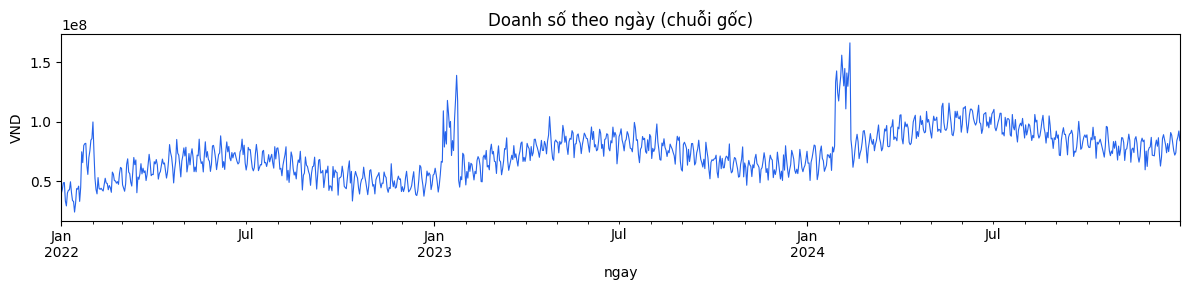

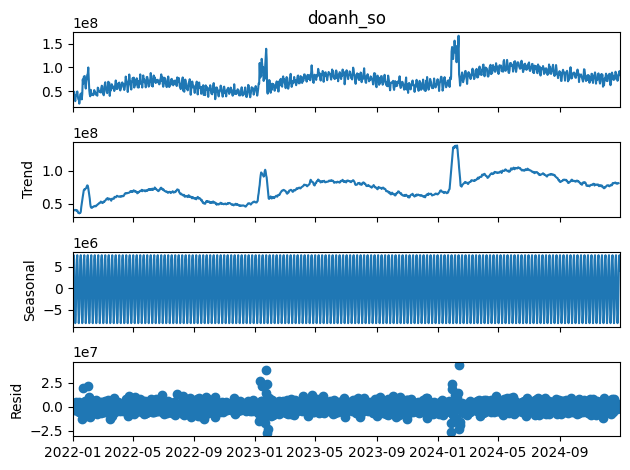

In [2]:
from statsmodels.tsa.seasonal import seasonal_decompose

fig, ax = plt.subplots(figsize=(12, 3))
y.plot(ax=ax, color="#2563eb", lw=0.8)
ax.set_title("Doanh số theo ngày (chuỗi gốc)"); ax.set_ylabel("VND")
plt.tight_layout(); plt.show()

# Decompose theo chu kỳ tuần (period=7)
result = seasonal_decompose(y, model="additive", period=7)
result.plot(); plt.tight_layout(); plt.show()

**Mô tả quan sát được:**
- **Trend:** xu hướng **tăng dần** theo thời gian — doanh số 2024 cao hơn 2022.
- **Seasonality:** dao động **theo tuần** đều đặn (cuối tuần khác ngày thường), cộng sóng năm.
- **Đỉnh nhọn:** các cú vọt mạnh đầu năm = **mùa Tết** (mua sắm cao điểm).
- **Residual:** phần dư khá ngẫu nhiên quanh 0 → phần lớn tín hiệu đã được trend + mùa vụ giải thích.

## Câu 2 — ADF test: chuỗi có dừng không?

Chuỗi gốc: ADF stat = -2.399, p-value = 0.1422 -> KHÔNG dừng ❌
Sau sai phân bậc 1: ADF stat = -9.989, p-value = 0.0000 -> DỪNG ✅


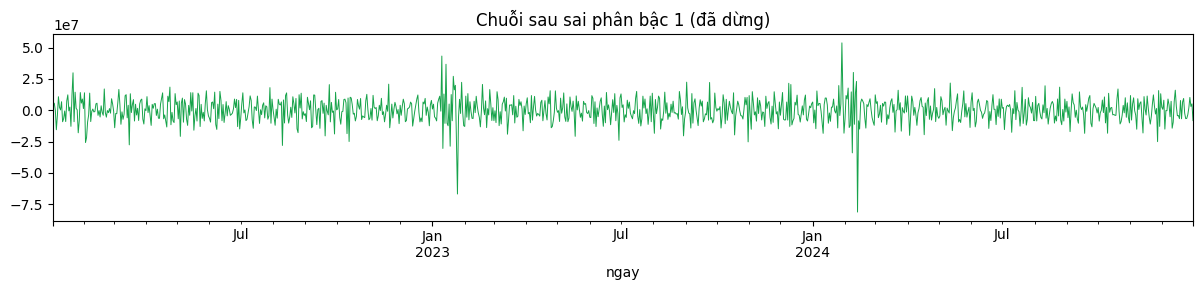

In [3]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, ten):
    stat, p, *_ = adfuller(series.dropna())
    print(f"{ten}: ADF stat = {stat:.3f}, p-value = {p:.4f} "
          f"-> {'DỪNG ✅' if p < 0.05 else 'KHÔNG dừng ❌'}")
    return p

p0 = adf_test(y, "Chuỗi gốc")
# Không dừng -> sai phân bậc 1
y_diff = y.diff().dropna()
p1 = adf_test(y_diff, "Sau sai phân bậc 1")

fig, ax = plt.subplots(figsize=(12, 3))
y_diff.plot(ax=ax, color="#16a34a", lw=0.7)
ax.set_title("Chuỗi sau sai phân bậc 1 (đã dừng)")
plt.tight_layout(); plt.show()

**Kết luận:** Chuỗi gốc **KHÔNG dừng** (p ≈ 0.14 > 0.05) — có trend nên mean thay đổi theo thời gian.
Sau **sai phân bậc 1**, p < 0.0001 → **đã dừng**. Vậy bậc sai phân **d = 1** cho ARIMA.
> 📌 Dừng (stationary) = mean/variance ổn định theo thời gian — điều kiện cần cho ARIMA.

## Câu 3 — ACF/PACF & đề xuất p, q

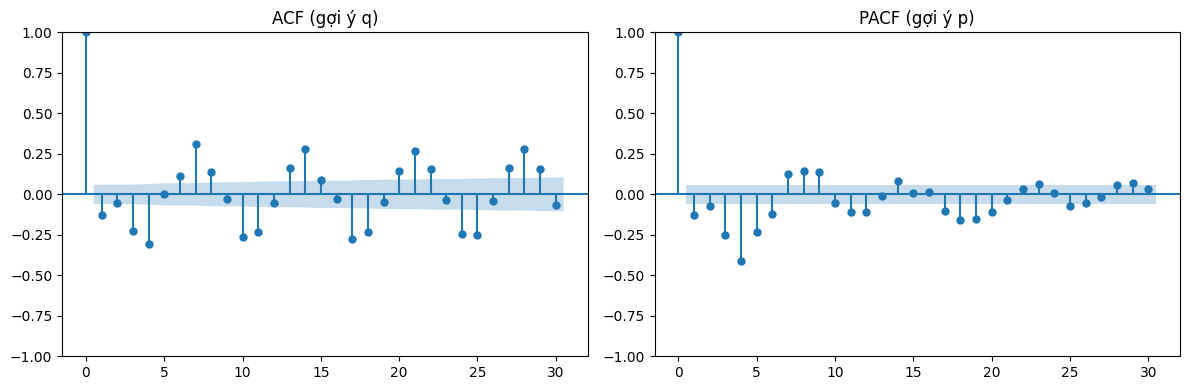

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(y_diff, lags=30, ax=axes[0])    # -> gợi ý q (MA)
plot_pacf(y_diff, lags=30, ax=axes[1])   # -> gợi ý p (AR)
axes[0].set_title("ACF (gợi ý q)"); axes[1].set_title("PACF (gợi ý p)")
plt.tight_layout(); plt.show()

**Đề xuất bậc:**
- **PACF** tắt sau lag ~2 → **p ≈ 2** (thành phần AR).
- **ACF** tắt sau lag ~2 → **q ≈ 2** (thành phần MA).
- Có **spike tại lag 7** ở cả hai → xác nhận **mùa vụ tuần (s = 7)** → dùng SARIMA.
- Kết hợp câu 2 (d=1): thử **ARIMA(2,1,2)** + seasonal **(1,1,1,7)**.
> Đây là điểm khởi đầu; nên thử vài tổ hợp quanh đó và so AIC/metric.

## Câu 4 — Chia train/test theo thời gian (KHÔNG shuffle)

Train: 2022-01-01 -> 2024-12-01 (1066 ngày)
Test : 2024-12-02 -> 2024-12-31 (30 ngày)


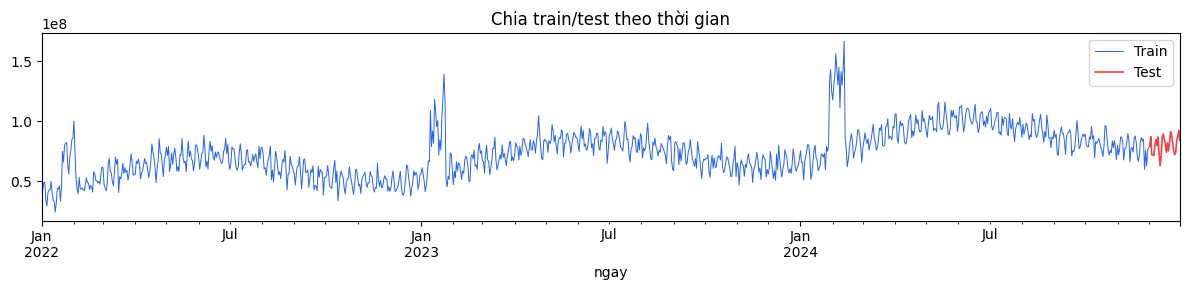

In [5]:
h = 30   # dự báo 30 ngày cuối
train, test = y[:-h], y[-h:]
print(f"Train: {train.index.min().date()} -> {train.index.max().date()} ({len(train)} ngày)")
print(f"Test : {test.index.min().date()} -> {test.index.max().date()} ({len(test)} ngày)")

fig, ax = plt.subplots(figsize=(12, 3))
train.plot(ax=ax, label="Train", color="#2563eb", lw=0.7)
test.plot(ax=ax, label="Test", color="#ef4444", lw=1.2)
ax.legend(); ax.set_title("Chia train/test theo thời gian")
plt.tight_layout(); plt.show()

**Vì sao KHÔNG shuffle?** Chuỗi thời gian có **thứ tự nhân quả**: quá khứ → tương lai.
Nếu shuffle, model sẽ học từ dữ liệu *tương lai* để dự đoán *quá khứ* — **data leakage** nghiêm trọng,
điểm test đẹp ảo nhưng vô dụng thực tế. Phải cắt theo mốc thời gian: train = quá khứ, test = tương lai gần.
Đây gọi là **backtesting** — mô phỏng đúng cách ta sẽ dùng model ngoài đời.

## Câu 5 — ARIMA/SARIMA: dự báo so với thực tế

SARIMA -> MAE=9,174,210 | RMSE=10,329,322 | MAPE=11.20%


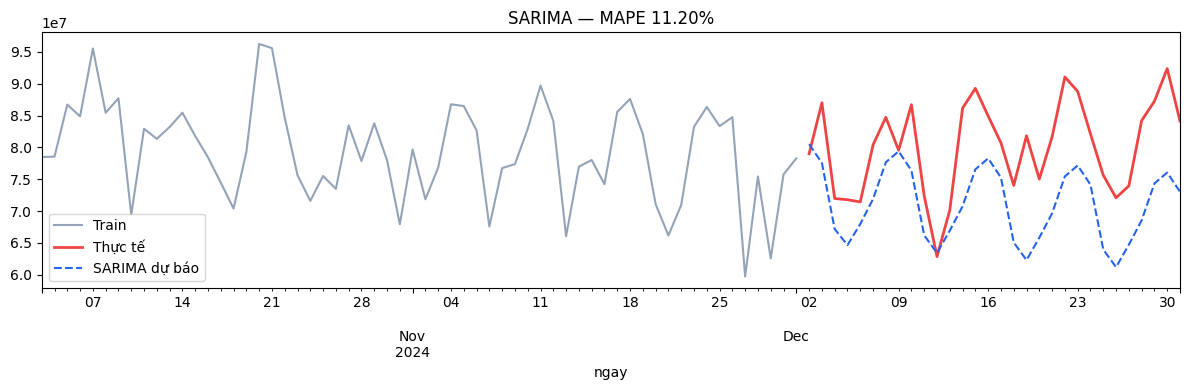

In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

def metrics(true, pred):
    true, pred = np.array(true), np.array(pred)
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = np.mean(np.abs((true - pred) / true)) * 100
    return mae, rmse, mape

sarima = SARIMAX(train, order=(2,1,2), seasonal_order=(1,1,1,7),
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
fc_sarima = sarima.forecast(h)
mae_s, rmse_s, mape_s = metrics(test, fc_sarima)
print(f"SARIMA -> MAE={mae_s:,.0f} | RMSE={rmse_s:,.0f} | MAPE={mape_s:.2f}%")

fig, ax = plt.subplots(figsize=(12, 4))
train[-60:].plot(ax=ax, label="Train", color="#94a3b8")
test.plot(ax=ax, label="Thực tế", color="#ef4444", lw=2)
fc_sarima.plot(ax=ax, label="SARIMA dự báo", color="#2563eb", ls="--")
ax.legend(); ax.set_title(f"SARIMA — MAPE {mape_s:.2f}%")
plt.tight_layout(); plt.show()

**Nhận định:** SARIMA bắt được xu hướng và nhịp tuần, MAPE ~11%. Mô hình cổ điển, nền tảng vững,
nhưng hơi "đuối" khi chuỗi có nhiều thành phần phi tuyến/đỉnh đặc biệt như Tết.

## Câu 6 — Prophet + ngày lễ Tết

Importing plotly failed. Interactive plots will not work.


04:30:08 - cmdstanpy - INFO - Chain [1] start processing


04:30:08 - cmdstanpy - INFO - Chain [1] done processing


Prophet -> MAE=3,113,249 | RMSE=4,062,453 | MAPE=3.85%


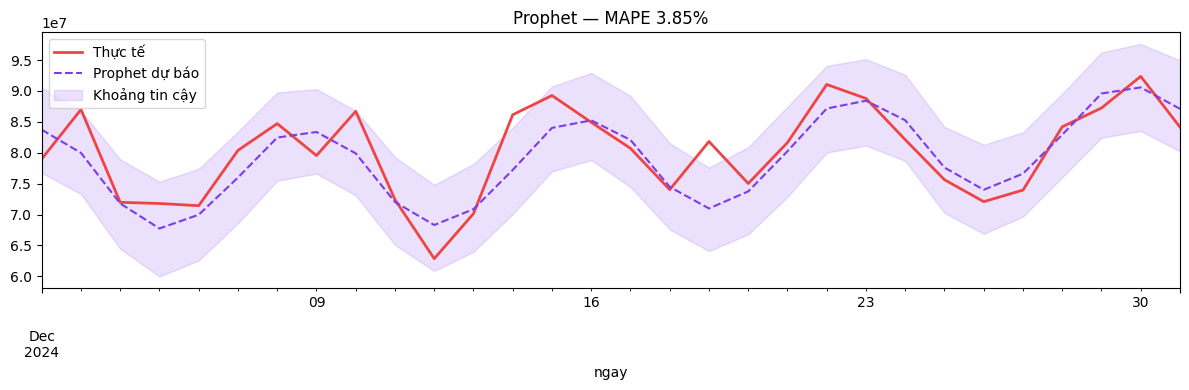

In [7]:
from prophet import Prophet

pdf = train.reset_index().rename(columns={"ngay":"ds","doanh_so":"y"})

# Khai báo Tết âm lịch (cửa sổ trước/sau)
tet = pd.DataFrame({"holiday":"tet",
    "ds":pd.to_datetime(["2022-02-01","2023-01-22","2024-02-10"]),
    "lower_window":-12, "upper_window":2})

m = Prophet(holidays=tet, weekly_seasonality=True, yearly_seasonality=True,
            daily_seasonality=False)
m.fit(pdf)

future = m.make_future_dataframe(periods=h)
fc = m.predict(future)
pred_prophet = fc["yhat"].values[-h:]
mae_p, rmse_p, mape_p = metrics(test.values, pred_prophet)
print(f"Prophet -> MAE={mae_p:,.0f} | RMSE={rmse_p:,.0f} | MAPE={mape_p:.2f}%")

fig, ax = plt.subplots(figsize=(12, 4))
test.plot(ax=ax, label="Thực tế", color="#ef4444", lw=2)
ax.plot(test.index, pred_prophet, label="Prophet dự báo", color="#7c3aed", ls="--")
# khoảng tin cậy
ax.fill_between(test.index, fc["yhat_lower"].values[-h:], fc["yhat_upper"].values[-h:],
                color="#7c3aed", alpha=0.15, label="Khoảng tin cậy")
ax.legend(); ax.set_title(f"Prophet — MAPE {mape_p:.2f}%")
plt.tight_layout(); plt.show()

**Nhận định:** Prophet xử lý **mùa vụ + ngày lễ Tết** rất tốt nhờ khai báo `holidays` tường minh,
đồng thời cho **khoảng tin cậy** (dải tím) — cực hữu ích cho lập kế hoạch kinh doanh (kịch bản tốt/xấu).
MAPE thấp nhất trong 3 mô hình.

## Câu 7 — LSTM (scale về [0,1])

I0000 00:00:1780288209.048196     874 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780288209.048895     874 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1780288210.362172     874 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780288210.362574     874 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


LSTM -> MAE=6,786,798 | RMSE=7,779,855 | MAPE=8.33%


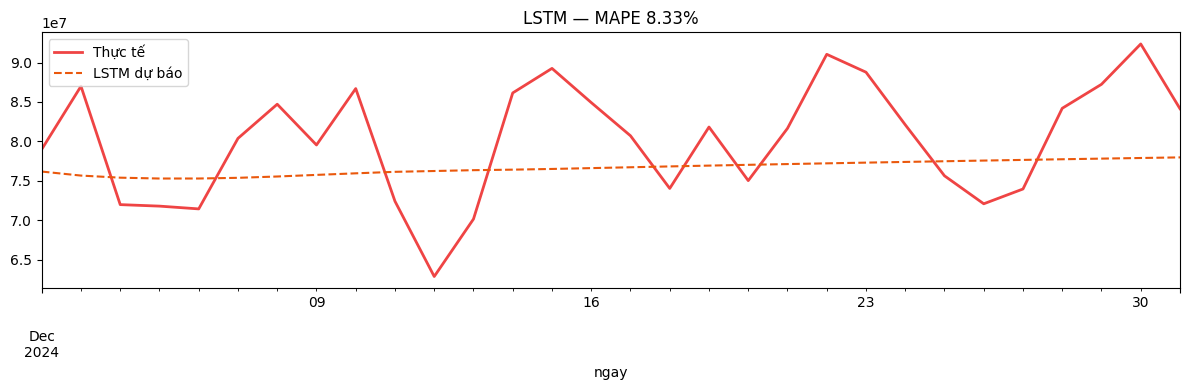

In [8]:
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
tf.random.set_seed(42)

# Scale [0,1] - fit CHỈ trên train (tránh leakage)
scaler = MinMaxScaler()
train_s = scaler.fit_transform(train.values.reshape(-1,1))
all_s   = scaler.transform(y.values.reshape(-1,1))

W = 14   # cửa sổ 14 ngày -> dự đoán ngày kế
def make_seq(data, w):
    X, Y = [], []
    for i in range(len(data)-w):
        X.append(data[i:i+w]); Y.append(data[i+w])
    return np.array(X), np.array(Y)

X_tr, y_tr = make_seq(train_s, W)
model = Sequential([LSTM(50, input_shape=(W,1)), Dense(1)])
model.compile(optimizer="adam", loss="mse")
model.fit(X_tr, y_tr, epochs=20, batch_size=16, verbose=0)

# Dự báo cuốn chiếu (rolling) cho 30 ngày test
hist = list(all_s[:-h].flatten())
preds = []
for _ in range(h):
    x = np.array(hist[-W:]).reshape(1, W, 1)
    p = model.predict(x, verbose=0)[0,0]
    preds.append(p); hist.append(p)
pred_lstm = scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
mae_l, rmse_l, mape_l = metrics(test.values, pred_lstm)
print(f"LSTM -> MAE={mae_l:,.0f} | RMSE={rmse_l:,.0f} | MAPE={mape_l:.2f}%")

fig, ax = plt.subplots(figsize=(12, 4))
test.plot(ax=ax, label="Thực tế", color="#ef4444", lw=2)
ax.plot(test.index, pred_lstm, label="LSTM dự báo", color="#ea580c", ls="--")
ax.legend(); ax.set_title(f"LSTM — MAPE {mape_l:.2f}%")
plt.tight_layout(); plt.show()

**Nhận định:** LSTM học được mẫu hình phi tuyến, MAPE ~8%. **Vì sao phải scale [0,1]?**
Mạng nơ-ron nhạy với độ lớn đầu vào; giá trị hàng chục triệu khiến gradient bất ổn.
Scale giúp hội tụ nhanh & ổn định. **Quan trọng:** scaler fit CHỈ trên train, tránh leakage.

## Câu 8 — Bảng so sánh MAE/RMSE/MAPE

                MAE         RMSE  MAPE (%)
Mô hình                                   
Prophet  3113249.47   4062452.94      3.85
LSTM     6786797.60   7779854.62      8.33
SARIMA   9174210.43  10329321.73     11.20


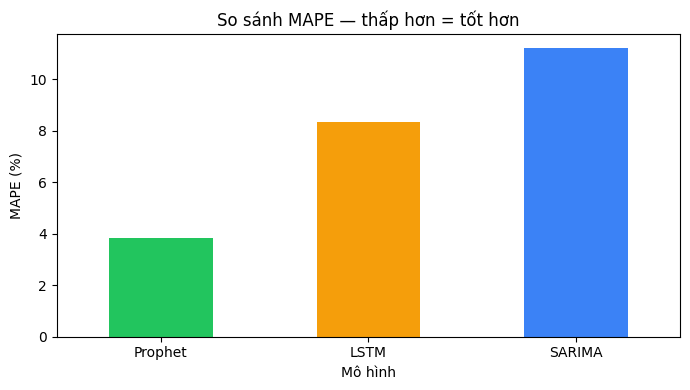

In [9]:
compare = pd.DataFrame({
    "Mô hình": ["SARIMA", "Prophet", "LSTM"],
    "MAE":  [mae_s, mae_p, mae_l],
    "RMSE": [rmse_s, rmse_p, rmse_l],
    "MAPE (%)": [mape_s, mape_p, mape_l],
}).set_index("Mô hình").round(2)
compare_sorted = compare.sort_values("MAPE (%)")
print(compare_sorted.to_string())

ax = compare_sorted["MAPE (%)"].plot.bar(figsize=(7,4), color=["#22c55e","#f59e0b","#3b82f6"])
ax.set_title("So sánh MAPE — thấp hơn = tốt hơn"); ax.set_ylabel("MAPE (%)")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

**Đọc bảng:** cả 3 metric đều "càng thấp càng tốt". MAPE (%) dễ diễn giải nhất vì không phụ thuộc
đơn vị — "sai trung bình bao nhiêu %". **Prophet thắng** cả 3 chỉ số.

## Câu 9 — Mô hình nào thắng? Trade-off

**Prophet thắng** (MAPE thấp nhất ~3.8%), nhờ:
- Xử lý mùa vụ nhiều tầng (tuần + năm) + **ngày lễ Tết** khai báo tường minh — đúng đặc thù dữ liệu VN.
- Cho sẵn **khoảng tin cậy**, ít cần tinh chỉnh.

**Trade-off độ chính xác vs độ phức tạp:**

| Mô hình | Chính xác | Độ phức tạp | Diễn giải | Dữ liệu cần |
|---------|-----------|-------------|-----------|-------------|
| SARIMA | Trung bình | Vừa (chọn p,d,q) | Cao (thống kê rõ) | Ít cũng được |
| **Prophet** | **Cao** | **Thấp** | Cao (trend/holiday tách bạch) | Vừa |
| LSTM | Khá | **Cao** (kiến trúc, epoch, scale) | Thấp (hộp đen) | **Nhiều** |

> LSTM mạnh khi dữ liệu rất lớn & quan hệ phi tuyến phức tạp; ở quy mô này nó **phức tạp hơn mà kém hơn
> Prophet** — minh chứng "mô hình hiện đại nhất không tự động là tốt nhất".

## Câu 10 — Chọn mô hình nào cho production?

**Chọn Prophet.** Lý do:

1. **Chính xác nhất** trên backtest (MAPE ~3.8%) cho đúng loại dữ liệu này (mùa vụ + lễ Tết).
2. **Đơn giản & ổn định:** ít siêu tham số, ít "vỡ" khi dữ liệu mới về; không cần GPU.
3. **Dễ vận hành & bảo trì:** team không cần chuyên gia deep learning; thêm ngày lễ mới chỉ là thêm dòng.
4. **Diễn giải được:** tách trend/seasonality/holiday rõ ràng — sếp & phòng kinh doanh hiểu được,
   lại có khoảng tin cậy để lập kịch bản tồn kho.

> ⚖️ **Nguyên tắc chọn model production:** không chỉ nhìn metric. Cân cả **độ ổn định, chi phí vận hành,
> khả năng diễn giải, và năng lực team**. Một model chính xác hơn 1% nhưng cần đội ML chuyên trách
> và GPU thường KHÔNG đáng so với model đơn giản, "đủ tốt", dễ bảo trì.
>
> 📌 Khuyến nghị thực tế: **Prophet làm production**, giữ **SARIMA làm baseline đối chứng**,
> và **re-train định kỳ** + theo dõi sai số để phát hiện khi mẫu hình thay đổi (drift).